# 01 — SAM 3 text-prompt inference

**Objetivo:** primera inferencia real con SAM 3 sobre frames de nuestro dataset usando **prompts de texto** (open vocabulary).

**Flujo:**
1. Carga modelo SAM 3 (`facebook/sam3`) en CPU, dtype `bfloat16` para ahorrar RAM
2. Extrae 2 frames del primer video del dataset
3. Aplica 3 prompts de texto: `"orange ball"`, `"robot"`, `"green field"`
4. Visualiza máscaras sobre los frames

**Tiempo estimado:** ~5 min en CPU (8 vCPU, 16 GB).

**Notas:**
- SAM 3 con prompt de texto detecta TODAS las instancias del concepto en la imagen (no solo una).
- Por eso el output trae `object_ids` (lista) y `obj_id_to_mask` (dict).
- En GPU pod (5090) esto corre ~50× más rápido.

## 1. Imports + paths

In [1]:
import os, sys, time
from pathlib import Path
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import decord
from transformers import AutoProcessor, AutoModel

WORKSPACE = Path('/workspace')
REPO = WORKSPACE / 'FutBotMX-UAQTeam'
SAM3_PATH = REPO / 'assets' / 'sam3'
DATA = REPO / 'data' / 'raw'  # symlink a /workspace/Meta_Glasses

print('Python:', sys.version.split()[0])
print('torch :', torch.__version__)
print('SAM 3 :', SAM3_PATH)
print('Data  :', DATA.resolve())

Python: 3.11.13
torch : 2.12.0+cpu
SAM 3 : /workspace/FutBotMX-UAQTeam/assets/sam3
Data  : /workspace/Meta_Glasses


## 2. Cargar SAM 3

Usamos `bfloat16` para ahorrar RAM (mitad que float32). En CPU pod con 16 GB RAM esto ocupa ~3.5 GB.

In [2]:
t0 = time.time()
processor = AutoProcessor.from_pretrained(str(SAM3_PATH))
model = AutoModel.from_pretrained(
    str(SAM3_PATH),
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)
model.eval()
print(f'Carga en {time.time()-t0:.1f}s')
print(f'Clase     : {type(model).__name__}')
print(f'Dispositivo: {next(model.parameters()).device}')
print(f'dtype     : {next(model.parameters()).dtype}')
print(f'Params    : {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

Carga en 9.9s
Clase     : Sam3VideoModel
Dispositivo: cpu
dtype     : torch.bfloat16
Params    : 859.9M


## 3. Extraer frames de un video

Tomamos el primer video del set `17Abril/Cámaras/` y sacamos 2 frames bien separados (inicio y mitad). Usamos `decord` que es rápido y seek-able.

In [3]:
VIDEO_PATH = sorted((DATA / '17Abril' / 'Cámaras').glob('*.MOV'))[0]
print('Video:', VIDEO_PATH.name)

vr = decord.VideoReader(str(VIDEO_PATH))
total_frames = len(vr)
fps = vr.get_avg_fps()
print(f'  Frames totales: {total_frames}')
print(f'  FPS: {fps:.1f}')
print(f'  Duración: {total_frames/fps:.1f} s')

# Frames de muestra (inicio y mitad)
FRAME_INDICES = [0, total_frames // 2]
frames_np = vr.get_batch(FRAME_INDICES).asnumpy()  # (N, H, W, 3)
frames_pil = [Image.fromarray(f) for f in frames_np]
print(f'\nFrames extraídos en índices {FRAME_INDICES}, shape: {frames_np.shape}')

Video: IMG_9779.MOV


  Frames totales: 1044
  FPS: 30.0
  Duración: 34.8 s

Frames extraídos en índices [0, 522], shape: (2, 1080, 1920, 3)


## 4. Visualizar frames originales

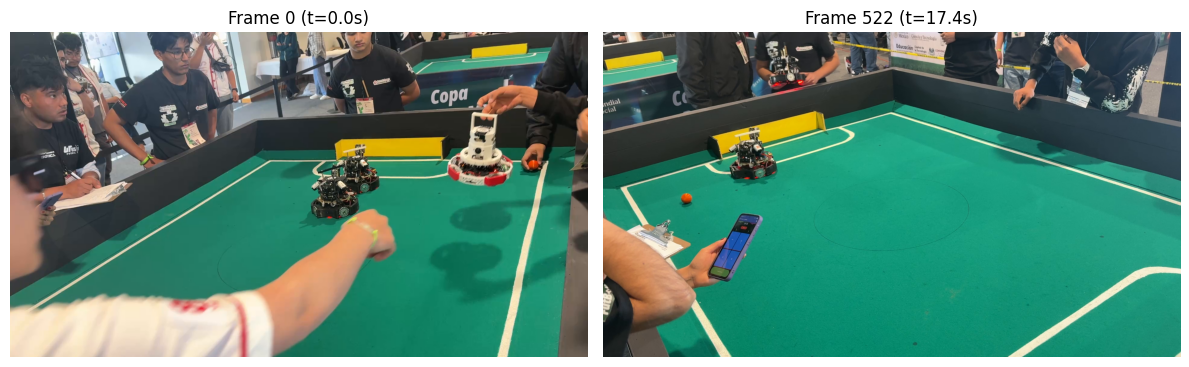

In [4]:
fig, axes = plt.subplots(1, len(frames_pil), figsize=(12, 8))
if len(frames_pil) == 1:
    axes = [axes]
for ax, img, idx in zip(axes, frames_pil, FRAME_INDICES):
    ax.imshow(img)
    ax.set_title(f'Frame {idx} (t={idx/fps:.1f}s)')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Helper de inferencia

SAM 3 con texto usa un patrón de **inference session**:
1. `init_video_session([imagen])` — crea estado de inferencia
2. `add_text_prompt(session, text="...")` — agrega prompt
3. `model(inference_session=session, frame_idx=0)` — corre forward
4. Output trae `obj_id_to_mask`, `object_ids`, `obj_id_to_score`

Como es open-vocabulary, puede devolver 0, 1 o varias máscaras (una por instancia detectada).

In [5]:
@torch.no_grad()
def segment_with_text(image: Image.Image, text: str):
    """Devuelve lista de (obj_id, mask_np_bool, score) para el prompt."""
    session = processor.init_video_session(
        video=[image],
        inference_device='cpu',
        dtype=torch.bfloat16,
    )
    session = processor.add_text_prompt(session, text=text)
    out = model(inference_session=session, frame_idx=0)

    results = []
    for obj_id in out.object_ids:
        mask = out.obj_id_to_mask[obj_id]
        score = float(out.obj_id_to_score.get(obj_id, 0.0))
        # mask viene como tensor; pásalo a numpy bool 2D (H,W)
        m = mask.detach().cpu().float().numpy()
        if m.ndim == 4:
            m = m[0, 0]
        elif m.ndim == 3:
            m = m[0]
        results.append((int(obj_id), m > 0.0, score))
    return results

## 6. Prompts de texto

Estos son los prompts que probamos. **Cambiar aquí pa' explorar otros conceptos.**

SAM 3 entiende open-vocabulary — puedes pedirle cualquier cosa describible en lenguaje natural.

In [6]:
PROMPTS = [
    'orange ball',
    'robot',
    'green field',
]
print('Prompts:')
for p in PROMPTS:
    print(f'  - "{p}"')

Prompts:
  - "orange ball"
  - "robot"
  - "green field"


## 7. Inferencia

Loop sobre frames × prompts. Cada inferencia tarda ~20-40 s en CPU.

In [7]:
# results_grid[(frame_idx, prompt)] = list of (obj_id, mask_bool, score)
results_grid = {}
for fi, img in enumerate(frames_pil):
    for prompt in PROMPTS:
        t0 = time.time()
        res = segment_with_text(img, prompt)
        dt = time.time() - t0
        n_inst = len(res)
        best_score = max((s for _, _, s in res), default=0.0)
        print(f'frame={fi} prompt="{prompt:15s}" → {n_inst} instancias, best_score={best_score:.3f}, {dt:.1f}s')
        results_grid[(fi, prompt)] = res

[transformers] kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.


frame=0 prompt="orange ball    " → 1 instancias, best_score=0.859, 10.3s


frame=0 prompt="robot          " → 3 instancias, best_score=0.961, 8.3s


frame=0 prompt="green field    " → 0 instancias, best_score=0.000, 8.3s


frame=1 prompt="orange ball    " → 1 instancias, best_score=0.902, 8.4s


frame=1 prompt="robot          " → 2 instancias, best_score=0.930, 8.4s


frame=1 prompt="green field    " → 0 instancias, best_score=0.000, 8.2s


## 8. Visualización — grid de frames × prompts

Cada celda muestra el frame con la máscara overlay para ese prompt. Si hay varias instancias detectadas, las dibuja todas con colores distintos.

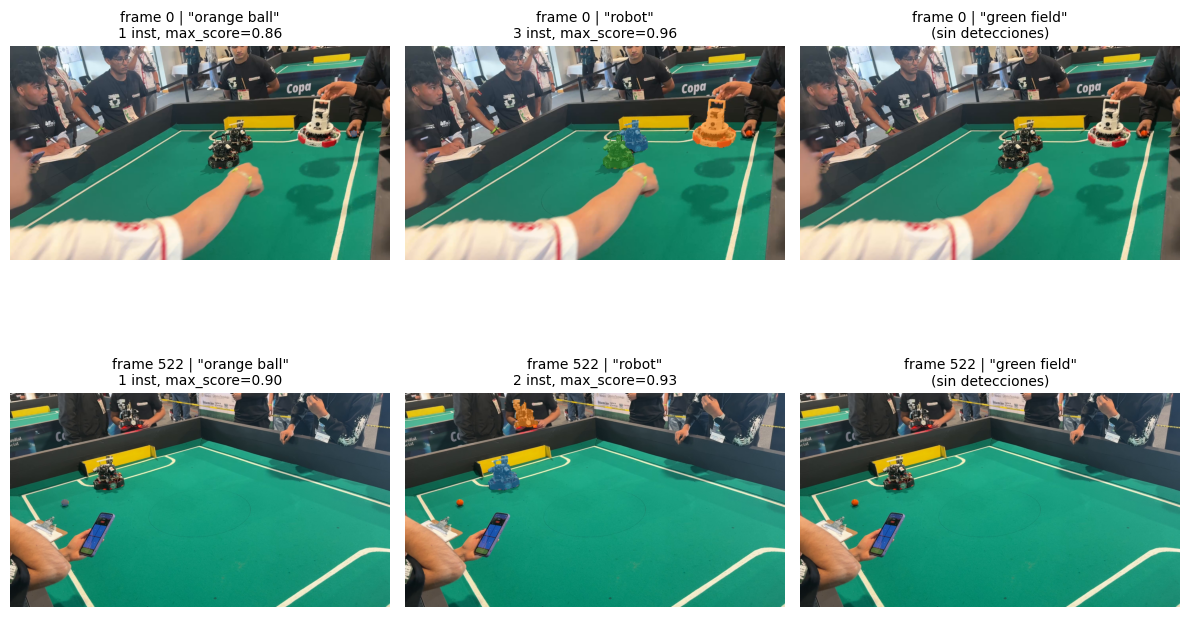

In [8]:
def overlay_masks(image_pil: Image.Image, results):
    """Devuelve imagen RGBA con masks superpuestas (una por instancia)."""
    img = np.array(image_pil).astype(np.float32) / 255.0  # H,W,3
    H, W, _ = img.shape
    overlay = img.copy()
    cmap = plt.get_cmap('tab10')
    for i, (obj_id, mask, score) in enumerate(results):
        # Resize máscara si no coincide
        if mask.shape != (H, W):
            mask = np.array(Image.fromarray(mask.astype(np.uint8)*255).resize((W, H), Image.NEAREST)) > 0
        color = np.array(cmap(i % 10)[:3])
        overlay[mask] = 0.4 * overlay[mask] + 0.6 * color
    return overlay

n_frames = len(frames_pil)
n_prompts = len(PROMPTS)
fig, axes = plt.subplots(n_frames, n_prompts, figsize=(4*n_prompts, 4*n_frames))
if n_frames == 1:
    axes = np.array([axes])
if n_prompts == 1:
    axes = axes.reshape(-1, 1)

for fi, img in enumerate(frames_pil):
    for pi, prompt in enumerate(PROMPTS):
        res = results_grid[(fi, prompt)]
        ax = axes[fi, pi]
        if not res:
            ax.imshow(img)
            ax.set_title(f'frame {FRAME_INDICES[fi]} | "{prompt}"\n(sin detecciones)', fontsize=10)
        else:
            ax.imshow(overlay_masks(img, res))
            best = max(s for _, _, s in res)
            ax.set_title(f'frame {FRAME_INDICES[fi]} | "{prompt}"\n{len(res)} inst, max_score={best:.2f}', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Próximos pasos

- **02_sam3_box_prompt.ipynb**: usar bbox manual (más preciso que text para objetos pequeños/ambiguos).
- **03_sam3_points_prompt.ipynb**: usar puntos foreground/background — útil cuando text es ambiguo.
- **04_sam3_video_tracking.ipynb**: tracking continuo a lo largo del video (SAM 3 propaga máscaras frame a frame).
- **Fase 1 (training)**: LoRA fine-tuning para mejorar detección de tus 5 objetos específicos.

**Si los resultados aquí no son buenos:**
- Probar prompts más específicos (e.g. `"orange soccer ball on green field"`).
- Cambiar a bbox prompts (mejor para objetos pequeños como la pelota).
- Esperar a GPU pod 5090 — algunas inferencias CPU dan menor calidad de máscara por falta de la lib `kernels` (post-processing NMS).